In [1]:
from general_utils import find_ephys_sessions
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names, get_fitted_latent
_, _, sessions = find_ephys_sessions()
from behavior_qc_metrics_summary import collect_behavior_model_summary
summary=collect_behavior_model_summary(session_paths=['/root/capsule/scratch/general_behavior/812561/812561_2025-10-25_17-37-30.nwb'])

Found behavior NWB: /root/capsule/scratch/general_behavior/812561/812561_2025-10-25_17-37-30.nwb


/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Successfully read behavior NWB from: /root/capsule/scratch/general_behavior/812561/812561_2025-10-25_17-37-30.nwb
No entries for alias 'QLearning_L2F1_CK1_softmax' in fit results
No entries for alias 'QLearning_L2F1_CK1_softmax' in fit results


In [2]:
summary['QLearning_L1F1_CKfull_softmax_deltaQ_entropy']

0    2.861287
Name: QLearning_L1F1_CKfull_softmax_deltaQ_entropy, dtype: float64

In [4]:
for c in summary.columns:
    print(c)


session
QLearning_L1F1_CK1_softmax_learn_rate_rew
QLearning_L1F1_CK1_softmax_learn_rate_unrew
QLearning_L1F1_CK1_softmax_forget_rate_unchosen
QLearning_L1F1_CK1_softmax_choice_kernel_relative_weight
QLearning_L1F1_CK1_softmax_choice_kernel_step_size
QLearning_L1F1_CK1_softmax_biasL
QLearning_L1F1_CK1_softmax_softmax_inverse_temperature
QLearning_L1F1_CK1_softmax_learn_rate
QLearning_L1F1_CK1_softmax_log_likelihood
QLearning_L1F1_CK1_softmax_AIC
QLearning_L1F1_CK1_softmax_BIC
QLearning_L1F1_CK1_softmax_LPT
QLearning_L1F1_CK1_softmax_LPT_AIC
QLearning_L1F1_CK1_softmax_LPT_BIC
QLearning_L1F1_CK1_softmax_prediction_accuracy
QLearning_L1F1_CK1_softmax_deltaQ_n
QLearning_L1F1_CK1_softmax_deltaQ_mean
QLearning_L1F1_CK1_softmax_deltaQ_std
QLearning_L1F1_CK1_softmax_deltaQ_iqr
QLearning_L1F1_CK1_softmax_deltaQ_q95_q5
QLearning_L1F1_CK1_softmax_deltaQ_mad
QLearning_L1F1_CK1_softmax_deltaQ_tie_frac
QLearning_L1F1_CK1_softmax_deltaQ_eps_used
QLearning_L1F1_CK1_softmax_deltaQ_entropy
QLearning_L1F1

In [ ]:
from general_utils import find_ephys_sessions
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names, get_fitted_latent
_, _, sessions = find_ephys_sessions()
from behavior_qc_metrics_summary import collect_behavior_model_summary
summary=collect_behavior_model_summary(sessions=sessions)

In [16]:
# run for all behavior sessions

import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
from tqdm import tqdm  # Import tqdm for progress bar
from behavior_qc_metrics_summary import collect_behavior_model_summary
from general_utils import find_ephys_sessions
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names, get_fitted_latent

# Define the root directory (based on the folder structure you provided)
root_dir = "/root/capsule/data/behavior_nwb/"

# Initialize a list to store the full paths of all .nwb files
nwb_files = []

# Walk through all directories and files under the root directory
for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith(".nwb"):
            # Append the full path of each .nwb file
            nwb_files.append(os.path.join(root, file))




def _run_one_session(session_name: str) -> pd.DataFrame:
    df = collect_behavior_model_summary(session_paths=[session_name])
    if "session_name" not in df.columns:
        df = df.assign(session_name=session_name)
    return df

def collect_behavior_model_summary_parallel(
    session_paths,
    *,
    max_workers: int = 20,
) -> pd.DataFrame:
    dfs = []
    errors = []
    total_sessions = len(session_paths)
    
    # Initialize tqdm progress bar
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        fut_to_sess = {ex.submit(_run_one_session, s): s for s in session_paths}
        completed = 0  # Initialize the completed task counter
        
        # Wrap the as_completed in tqdm to show progress
        for fut in tqdm(as_completed(fut_to_sess), total=total_sessions, desc="Processing sessions", ncols=100):
            completed += 1  # Increment completed tasks count
            
            s = fut_to_sess[fut]
            
            try:
                dfs.append(fut.result())
            except Exception as e:
                errors.append((s, repr(e)))

    if errors:
        print("Some sessions failed:")
        for s, err in errors[:20]:
            print(f"  {s}: {err}")
        if len(errors) > 20:
            print(f"  ... plus {len(errors)-20} more")

    if not dfs:
        return pd.DataFrame()

    out = pd.concat(dfs, ignore_index=True, sort=False)

    if "session_name" in out.columns:
        out = out.sort_values(["session_name"]).reset_index(drop=True)

    return out

# Usage
summary = collect_behavior_model_summary_parallel(session_paths=nwb_files, max_workers=8)


# Save the summary to a CSV file in /root/capsule/scratch
output_path = '/root/capsule/scratch/behavior_model_summary_ephys_sessions.csv'
summary.to_csv(output_path, index=False)  # Save without the index column
print(f"Summary saved to {output_path}")




Found behavior NWB: /root/capsule/data/behavior_nwb/781471_2025-03-31_14-33-03.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/781471_2025-03-28_15-06-14.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753125_2024-10-15_16-16-22.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753126_2024-10-14_11-53-22.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/781471_2025-03-27_13-39-06.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753126_2024-10-15_12-20-35.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753125_2024-10-09_10-50-19.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753125_2024-10-10_14-41-23.nwb


Processing sessions:   0%|                                                   | 0/44 [00:00<?, ?it/s]/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/753126_2024-10-15_12-20-35.nwb
Found 8 MLE fitting records!
Found 8 successful MLE fitting!
Found 8 successful MLE fitting!










Get latent variables from s3: 100%|██████████| 8/8 [00:00<00:00,  8.92it/s]


Found 9 MLE fitting records!
Found 9 successful MLE fitting!
Found 8 MLE fitting records!
Found 8 successful MLE fitting!


Processing sessions:  11%|████▉                                      | 5/44 [00:23<01:31,  2.34s/it]

Found behavior NWB: /root/capsule/data/behavior_nwb/776293_2025-02-14_15-19-17.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/769884_2025-01-16_18-33-11.nwb


Processing sessions: 100%|██████████████████████████████████████████| 44/44 [01:47<00:00,  2.44s/it]


In [ ]:
# run for all behavior sessions

import os

# Define the root directory (based on the folder structure you provided)
root_dir = "/root/capsule/data/general_behavior/"

# Initialize a list to store the full paths of all .nwb files
nwb_files = []

# Walk through all directories and files under the root directory
for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith(".nwb"):
            # Append the full path of each .nwb file
            nwb_files.append(os.path.join(root, file))


import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
from tqdm import tqdm  # Import tqdm for progress bar
from behavior_qc_visualization import collect_behavior_model_summary
from general_utils import find_ephys_sessions
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names, get_fitted_latent

def _run_one_session(session_name: str) -> pd.DataFrame:
    df = collect_behavior_model_summary(session_paths=[session_name])
    if "session_name" not in df.columns:
        df = df.assign(session_name=session_name)
    return df

def collect_behavior_model_summary_parallel(
    session_paths,
    *,
    max_workers: int = 20,
) -> pd.DataFrame:
    dfs = []
    errors = []
    total_sessions = len(session_paths)
    
    # Initialize tqdm progress bar
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        fut_to_sess = {ex.submit(_run_one_session, s): s for s in session_paths}
        completed = 0  # Initialize the completed task counter
        
        # Wrap the as_completed in tqdm to show progress
        for fut in tqdm(as_completed(fut_to_sess), total=total_sessions, desc="Processing sessions", ncols=100):
            completed += 1  # Increment completed tasks count
            
            s = fut_to_sess[fut]
            
            try:
                dfs.append(fut.result())
            except Exception as e:
                errors.append((s, repr(e)))

    if errors:
        print("Some sessions failed:")
        for s, err in errors[:20]:
            print(f"  {s}: {err}")
        if len(errors) > 20:
            print(f"  ... plus {len(errors)-20} more")

    if not dfs:
        return pd.DataFrame()

    out = pd.concat(dfs, ignore_index=True, sort=False)

    if "session_name" in out.columns:
        out = out.sort_values(["session_name"]).reset_index(drop=True)

    return out

# Usage
summary = collect_behavior_model_summary_parallel(session_paths=nwb_files, max_workers=8)


# Save the summary to a CSV file in /root/capsule/scratch
output_path = '/root/capsule/scratch/behavior_model_summary.csv'
summary.to_csv(output_path, index=False)  # Save without the index column
print(f"Summary saved to {output_path}")




In [5]:
from IPython.display import HTML, display

display(HTML("<br>".join(summary.columns)))


In [18]:
import importlib
import behavior_qc_visualization

importlib.reload(behavior_qc_visualization)

from behavior_qc_visualization import load_behavior_model_summary_csv

summary=load_behavior_model_summary_csv('/root/capsule/scratch/behavior_model_summary_general_behavior.csv')

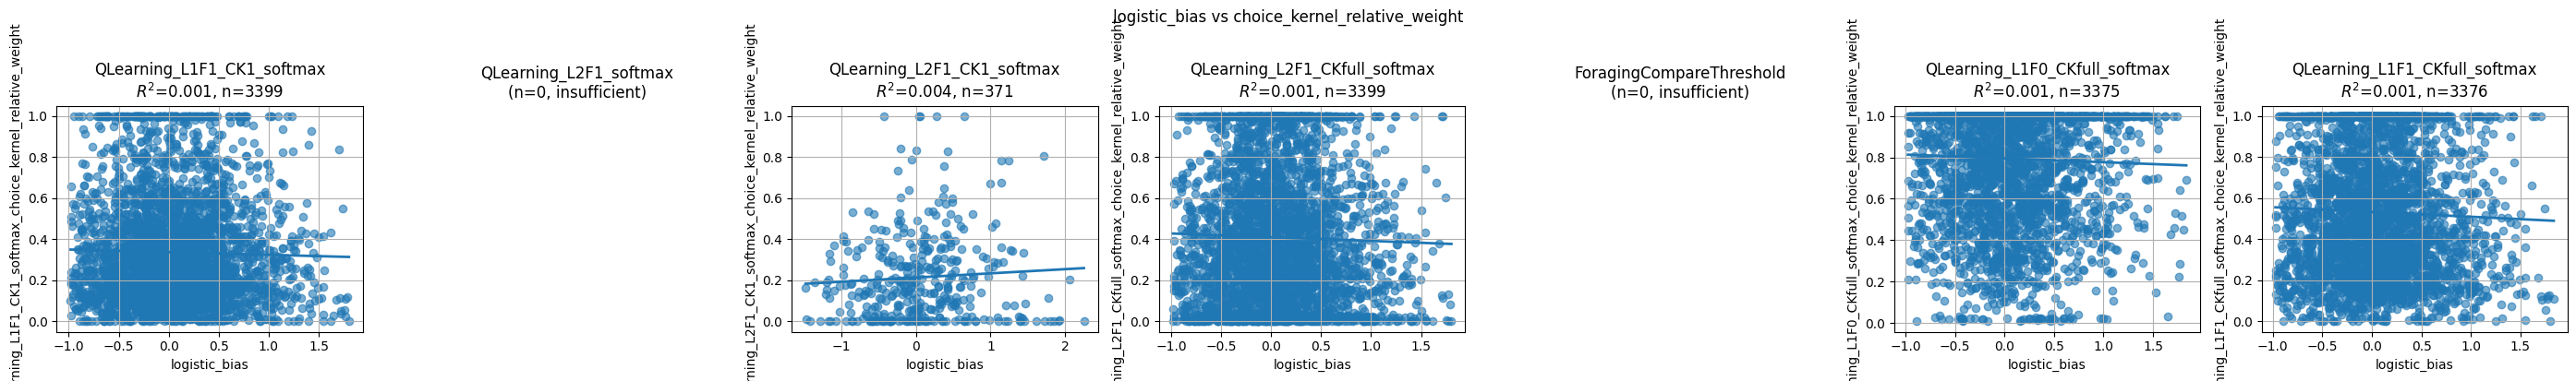

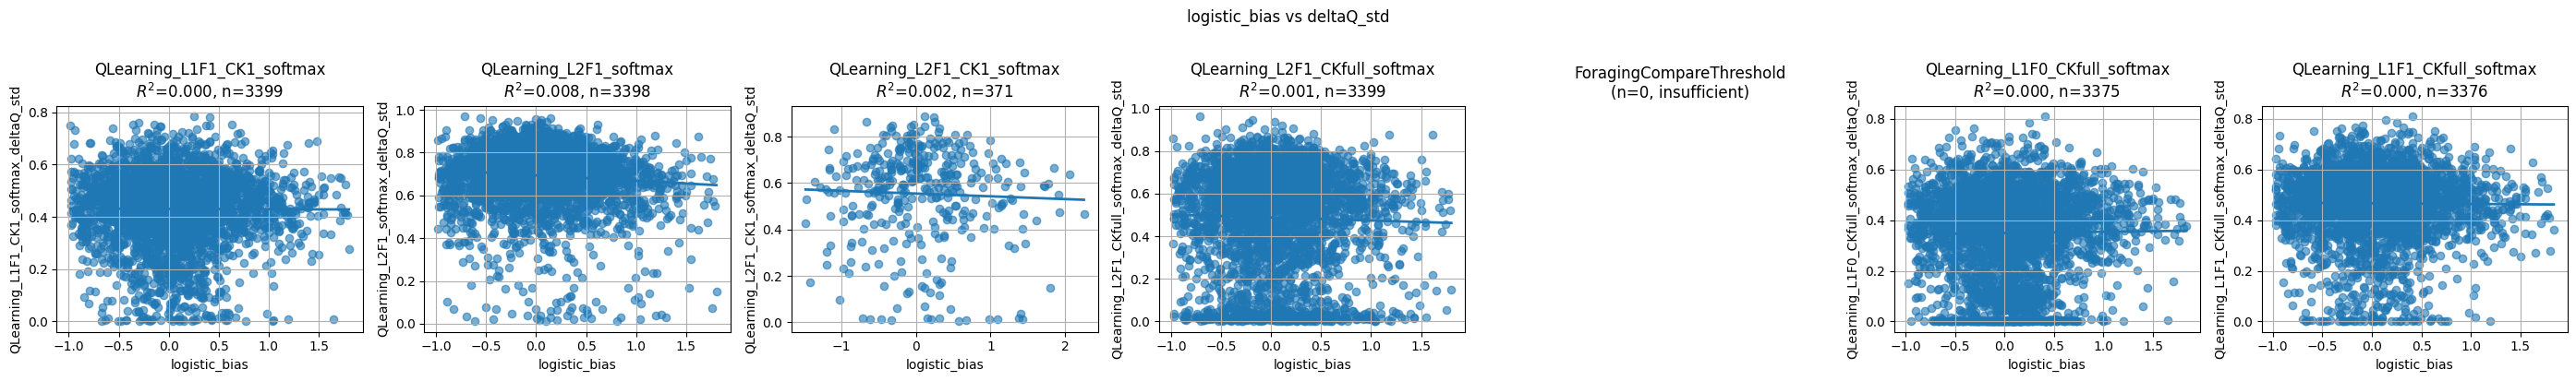

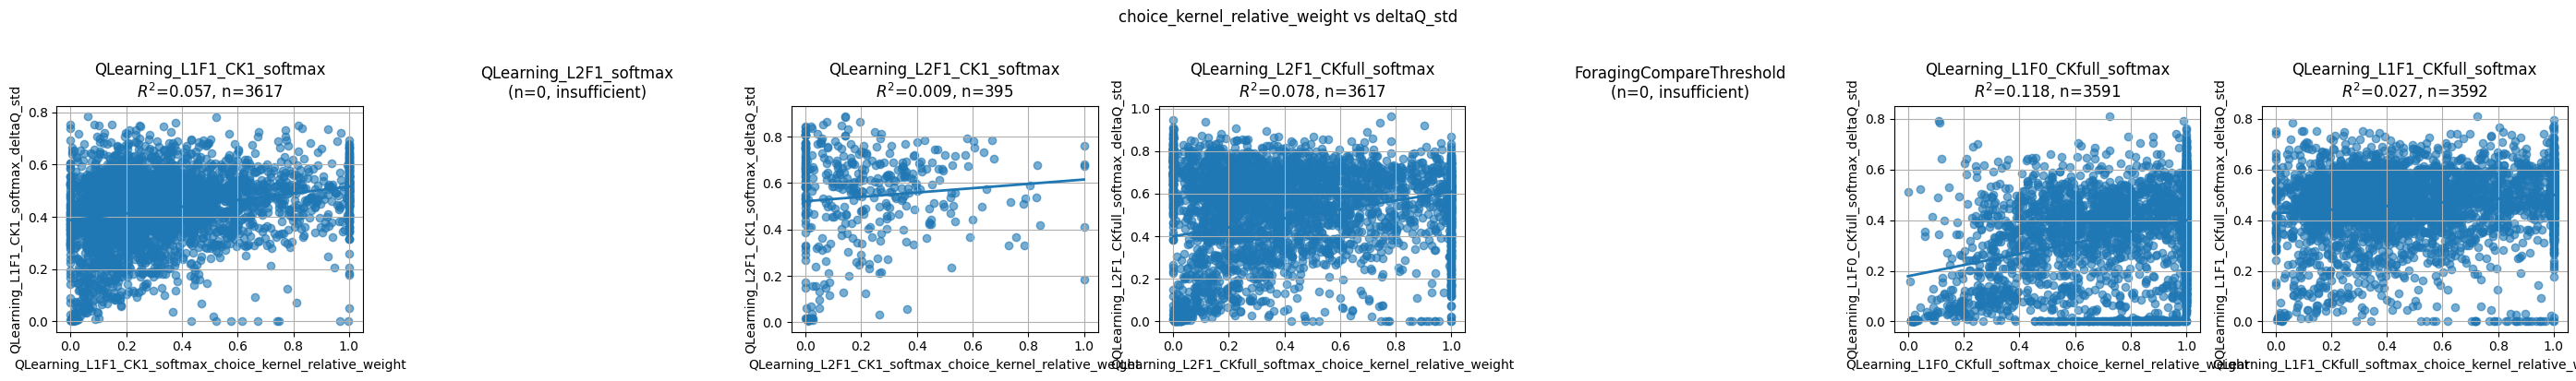

In [22]:
from itertools import combinations
from typing import Dict, Any
import importlib
import behavior_qc_visualization

importlib.reload(behavior_qc_visualization)

from behavior_qc_visualization import plot_x_vs_y_by_stage
# List of metric suffixes to pairwise compare (unordered: (A,B) == (B,A))
metrics = [
    "LPT",
    "reward_coefs_sum6",
    "choice_kernel_relative_weight",
    "learn_rate",
    "learn_rate_rew",
    "learn_rate_unrew",
    "biasL",
    "deltaQ_q95_q5",
    "deltaQ_mad",
    "deltaQ_tie_frac",
    "deltaQ_entropy",
    "sumQ_q95_q5",
    "sumQ_mad",
    "sumQ_tie_frac",
    "sumQ_entropy",
    "rpe_q95_q5",
    "rpe_mad",
    "rpe_tie_frac",
    "rpe_entropy",
]

metrics = [
    "LPT",
    "reward_coefs_sum6",
    "learn_rate",
    "learn_rate_rew",
    "learn_rate_unrew",
    "deltaQ_entropy",
    "sumQ_entropy",
    "rpe_entropy",
    "deltaQ_q95_q5",
    "sumQ_q95_q5",
    "rpe_q95_q5",
    "deltaQ_tie_frac",
    "sumQ_tie_frac",
    "rpe_tie_frac",
]



metrics = [
    "LPT",
    "reward_coefs_sum6",
    "learn_rate",
    "learn_rate_rew",
    "learn_rate_unrew",
    "deltaQ_mean",
    "deltaQ_std",
    "deltaQ_mad",
    "sumQ_mean",
    "sumQ_std",
    "sumQ_mad",
    "rpe_mean",
    "rpe_std",
    "rpe_mad",

]


metrics = [
    "LPT",
    "reward_coefs_sum6",
    "learn_rate",
    "deltaQ_std",
    "sumQ_std",
    "rpe_std",
]

metrics = [
    "reward_coefs_sum6",
    "learn_rate",
    "deltaQ_entropy",
    "sumQ_entropy",
    "rpe_entropy",
]

metrics = [
"choice_kernel_relative_weight",
"deltaQ_std",
]

# Choose your stage filter
stage = ["STAGE_FINAL"]

# Run all unordered combinations and store outputs
all_results: Dict[str, Any] = {}


for suffix_y in metrics:
    
    res = plot_x_vs_y_by_stage(
        summary,
        x_col='logistic_bias',
        suffix_y=suffix_y,
        xlim_percentiles=(0.05,0.99),
        stage=stage,
    )


for suffix_x, suffix_y in combinations(metrics, 2):
    key = f"{suffix_x}__vs__{suffix_y}"
    print(f"Plotting {key}")

    res = plot_x_vs_y_by_stage(
        summary,
        suffix_x=suffix_x,
        suffix_y=suffix_y,
        stage=stage,
    )
    all_results[key] = res





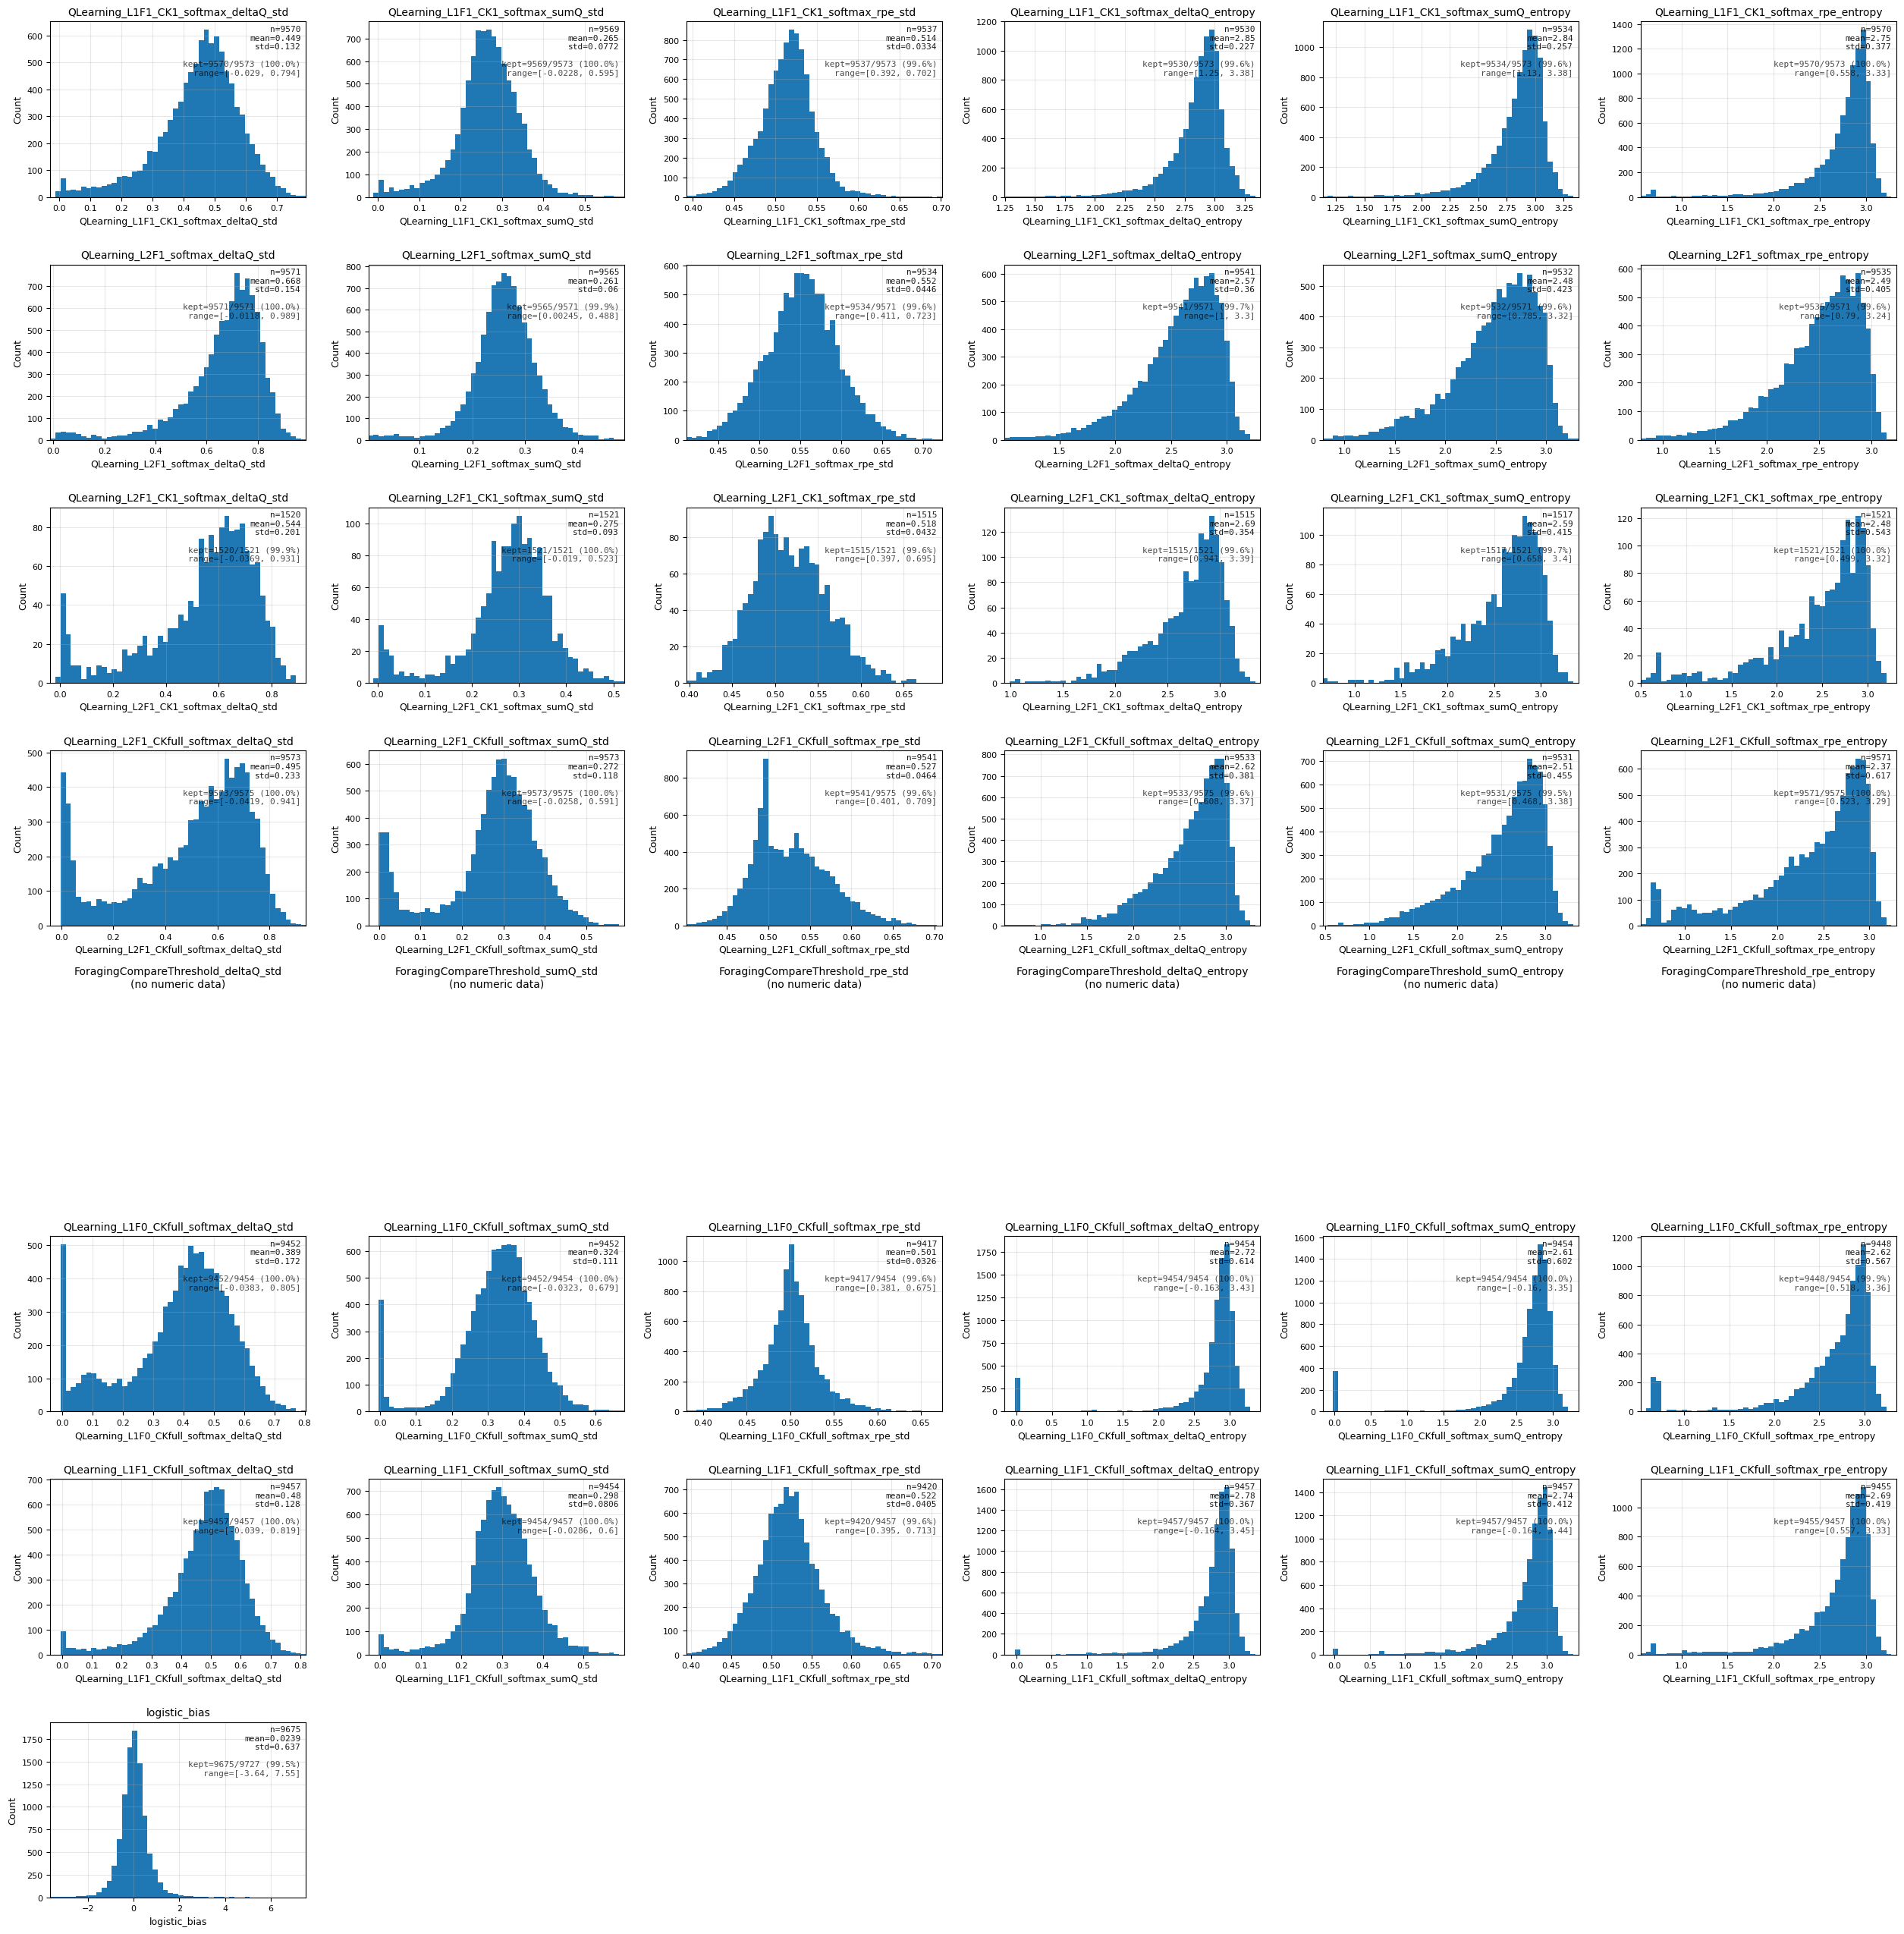

In [21]:
import importlib
import behavior_qc_visualization

importlib.reload(behavior_qc_visualization)

from behavior_qc_visualization import plot_summary_column_distributions


models = [
    "QLearning_L1F1_CK1_softmax",
    "QLearning_L2F1_softmax",
    "QLearning_L2F1_CK1_softmax",
    "QLearning_L2F1_CKfull_softmax",
    "ForagingCompareThreshold",
    "QLearning_L1F0_CKfull_softmax",
    "QLearning_L1F1_CKfull_softmax",
]

base_suffixes = [
    "LPT",
    "reward_coefs_sum6",
    "choice_kernel_relative_weight",
    "learn_rate",
    "learn_rate_rew",
    "learn_rate_unrew",
    "biasL"
    
]

base_suffixes = [
    "deltaQ_std",
    "sumQ_std",
    "rpe_std",
    "deltaQ_entropy",
    "sumQ_entropy",
    "rpe_entropy",
    
]


cols = [
    f"{model}_{suffix}"
    for model in models
    for suffix in base_suffixes
    if f"{model}_{suffix}" in summary.columns
]

# Optionally keep logistic_bias at the end
if "logistic_bias" in summary.columns:
    cols.append("logistic_bias")


fig, axes, stats = plot_summary_column_distributions(
    summary, cols,
    bins=50, ncols=6,
    xlim_percentiles=(0.5, 99.9),
    xlim_pad_frac=0.05,
)

